<a href="https://colab.research.google.com/github/Sikaaaa3/Lab-3/blob/main/lab_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Name : Janet Dankwah Nortey
Student ID: 23112028


In [75]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# You will import the specific sklearn modules you need inside each section.
# Example: from sklearn.model_selection import train_test_split

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)   # use this everywhere so your results are reproducible
np.random.seed(RANDOM_STATE)

print("Running on:", DEVICE)

Running on: cpu


Section 1 — Inside a Neural Network: From One Neuron to Gradient Descent

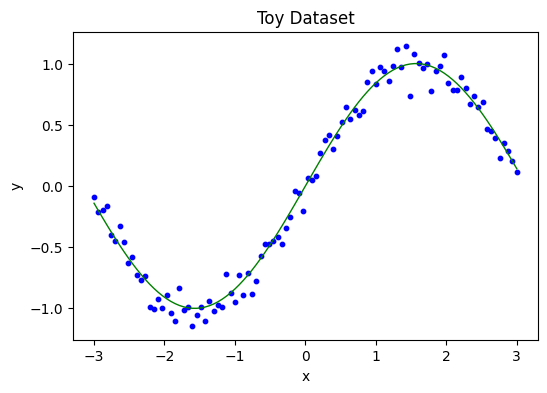

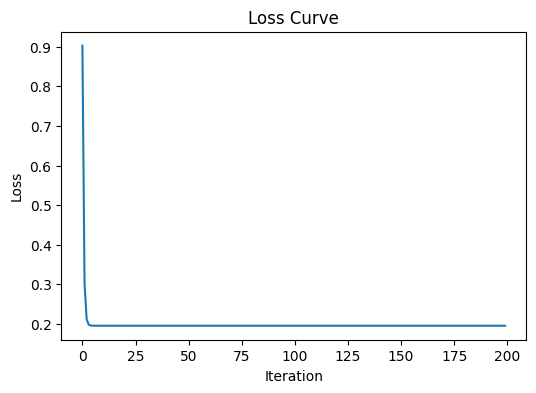

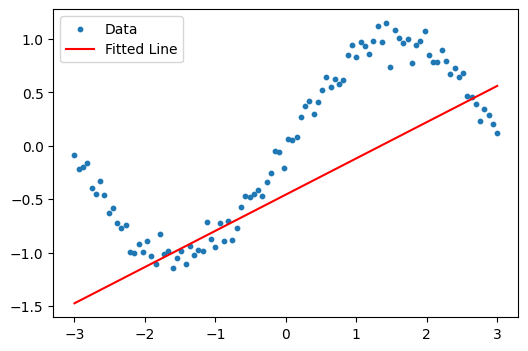

In [76]:
#Generate toy data
x = np.linspace(-3, 3, 100)
noise =np.random.normal(0,0.1,len(x))
y=np.sin(x) + noise

plt.figure(figsize=(6,4))
plt.scatter(x,y, s = 10, color="blue")
plt.plot(x, np.sin(x), color = "green", lw = 1, label = "true sin(x)")
plt. title("Toy Dataset")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

#Initialize parameters
w=np.random.randn() * 0.1
b=np.random.randn() *0.1

lr = 0.1
losses =[]

#Gradient Descent
for i in range(200):

  #Prediction
  y_hat = w * x

  #compute MSE loss
  loss = np.mean((y_hat - y) ** 2)
  losses.append(loss)

  #compute gradients
  dw=np.mean(2 * (y_hat - y) * x)
  db=np.mean(2 * (y_hat -y))

  #update parameters
  w-= lr * dw
  b-= lr * db

#Plot loss
plt.figure(figsize=(6,4))
plt.plot(losses)
plt.title("Loss Curve")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.show

#Plot fitted line
plt.figure(figsize=(6,4))
plt.scatter(x,y, s = 10, label="Data")
plt.plot(x,w * x+b, color = "red", label = "Fitted Line")
plt.legend()
plt.show()




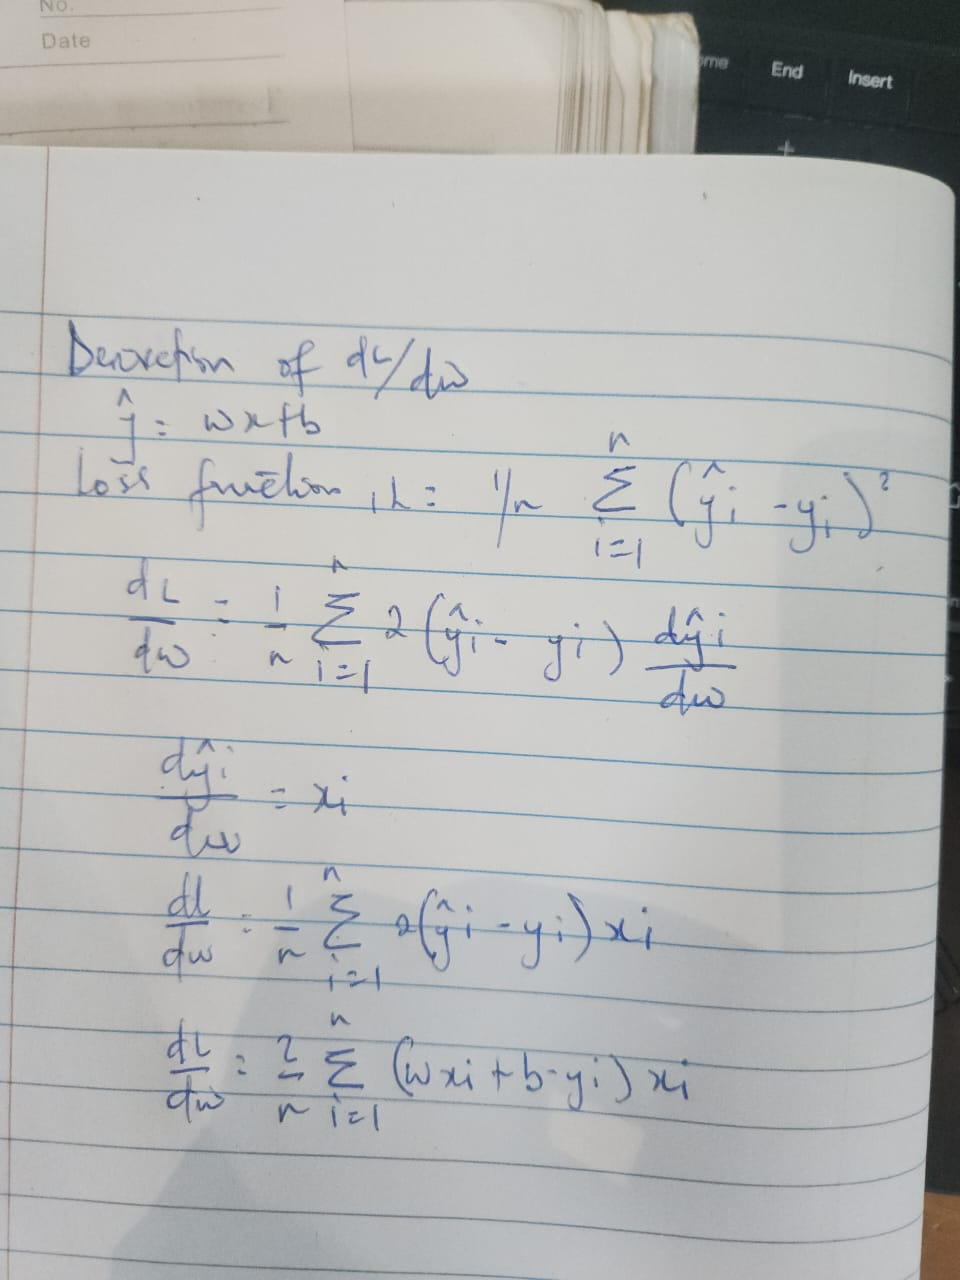

**Part** 1.2 — Hidden layers and activations: why depth helps

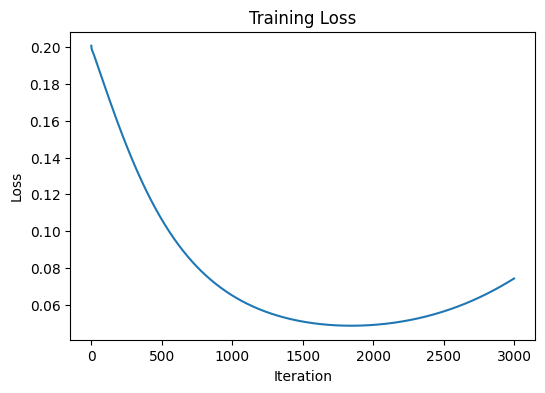

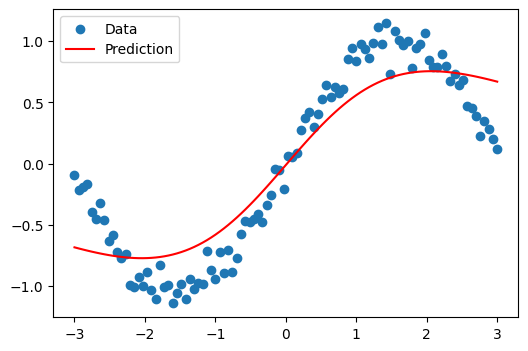

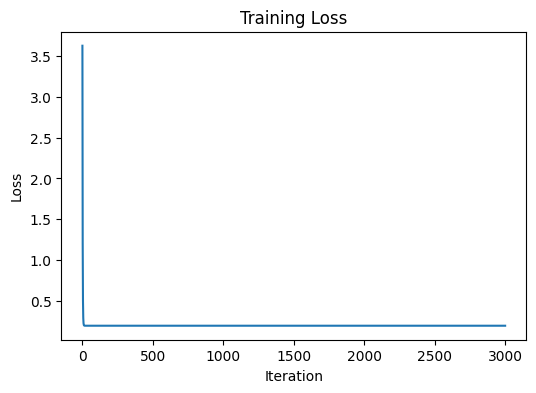

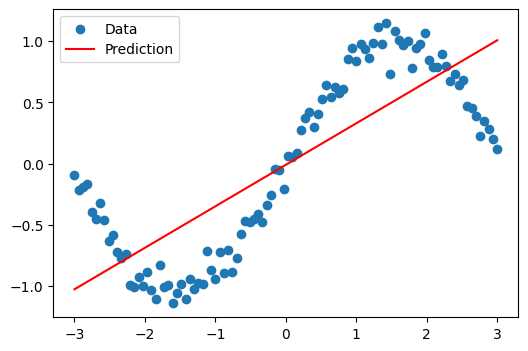

In [77]:
# Initialise parameter
x= x.reshape(-1,1)
y=y.reshape(-1,1)

W1 = np.random.randn(1, 8) * 0.5
b1 = np.zeros(8)

W2 = np.random.randn(8, 1) * 0.5
b2 = np.zeros(1)

lr = 0.01
losses = []

#Forward Pass
for i in range(3000):
      z1 = x @ W1 + b1
      h = np.tanh(z1)
      y_hat = h @ W2 + b2

      loss = np.mean((y_hat - y) ** 2)
      losses.append(loss)

      # Backwards Pass
      d_yhat = 2 * (y_hat - y) / len(y)

      dW2 = h.T @ d_yhat
      db2 = d_yhat.sum(axis=0)

      dh = d_yhat @ W2.T

      dz1 = dh
      dW1 = x.T @ dz1
      db1 = dz1.sum(axis=0)

      #Update the Parameters
      W1 -= lr * dW1
      b1 -= lr * db1

      W2 -= lr * dW2
      b2 -= lr * db2

#Plot the loss
plt.figure(figsize=(6,4))
plt.plot(losses)
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.show()

# Plot the final prediction
plt.figure(figsize=(6,4))
plt.scatter(x, y, label="Data")
plt.plot(x, y_hat, color="red", label="Prediction")
plt.legend()
plt.show()



#Re- Run with tanh

x= x.reshape(-1,1)
y=y.reshape(-1,1)

W1 = np.random.randn(1, 8) * 0.5
b1 = np.zeros(8)

W2 = np.random.randn(8, 1) * 0.5
b2 = np.zeros(1)

lr = 0.01
losses = []
#Forward Pass
for i in range(3000):
      z1 = x @ W1 + b1
      h = z1
      y_hat = h @ W2 + b2

      loss = np.mean((y_hat - y) ** 2)
      losses.append(loss)

      # Backwards Pass
      d_yhat = 2 * (y_hat - y) / len(y)

      dW2 = h.T @ d_yhat
      db2 = d_yhat.sum(axis=0)

      dh = d_yhat @ W2.T

      dz1 = dh

      dW1 = x.T @ dz1
      db1 = dz1.sum(axis=0)

      #Update the Parameters
      W1 -= lr * dW1
      b1 -= lr * db1

      W2 -= lr * dW2
      b2 -= lr * db2

#Plot the loss
plt.figure(figsize=(6,4))
plt.plot(losses)
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.show()

# Plot the final prediction
plt.figure(figsize=(6,4))
plt.scatter(x, y, label="Data")
plt.plot(x, y_hat, color="red", label="Prediction")
plt.legend()
plt.show()













1.When the tanh activation is removed, every layer in the network performs only a linear transformation. Combining multiple linear transformations is still equivalent to a single linear transformation, so adding more linear layers does not increase the model's ability to learn complex patterns. As a result, the deep network behaves like a single linear model and cannot fit nonlinear relationships any better than the single neuron in Part 1.1.

2.The 8 hidden neurons learned different nonlinear features of the input using the tanh activation. Each neuron captured a different part of the input pattern, and the output layer combined these learned features to produce a better fit to the curve. This allowed the network to model complex nonlinear relationships that a single neuron could not.

3.Backpropagation is the process of computing the gradients of the loss with respect to every parameter in the network using the chain rule, so the weights can be updated to reduce the loss.

Part 1.3 — The learning rate: too cold, too hot, just right


/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:127: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
/tmp/ipykernel_1035/2413940732.py:18: RuntimeWarning: overflow encountered in square
  loss = np.mean((y_hat - y) ** 2)
/tmp/ipykernel_1035/2413940732.py:25: RuntimeWarning: overflow encountered in matmul
  dh = d_yhat @ w2.T
/tmp/ipykernel_1035/2413940732.py:26: RuntimeWarning: invalid value encountered in multiply
  dz1 = dh * (1 - np.tanh(z1) ** 2)
/usr/local/lib/python3.12/dist-packages/matplotlib/scale.py:253: RuntimeWarning: overflow encountered in power
  return np.power(self.base, values)


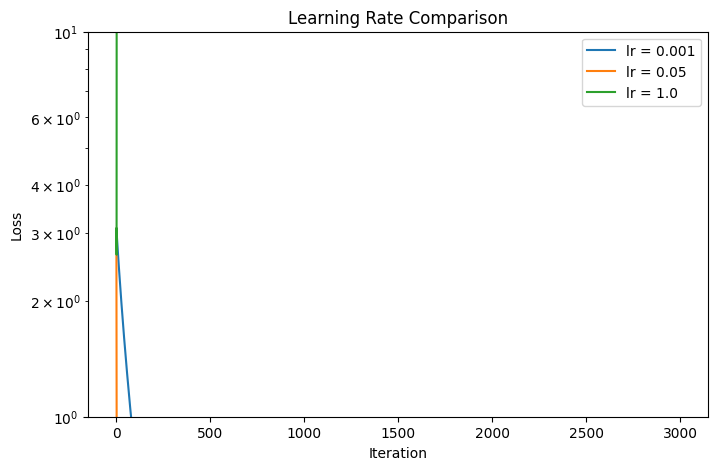

In [78]:
def train_toy(lr, steps=3000):
  np.random.seed(42)

  w1 = np.random.randn(1, 8) * 0.5
  b1 = np.zeros(8)

  w2 = np.random.randn(8, 1) * 0.5
  b2 = np.zeros(1)

  losses =[]

  for i in range(steps):
    #Forward pass
    z1 = x @ w1 + b1
    h = np.tanh(z1)
    y_hat = h @ w2 + b2

    loss = np.mean((y_hat - y) ** 2)
    losses.append(loss)

    #Backward pass
    d_yhat = 2 * (y_hat - y) / len(y)
    dW2 = h.T @ d_yhat
    db2 = d_yhat.sum(axis=0)
    dh = d_yhat @ w2.T
    dz1 = dh * (1 - np.tanh(z1) ** 2)
    dW1 = x.T @ dz1
    db1 = dz1.sum(axis=0)

    #update
    w1 -= lr * dW1
    b1 -= lr * db1

    w2 -= lr * dW2
    b2 -= lr * db2

  return losses

#Training with the three learning rates
loss1 = train_toy(0.001)
loss2 = train_toy(0.05)
loss3 = train_toy(1.0)


#Plot of the three graph
plt.figure(figsize=(8,5))

plt.plot(loss1, label="lr = 0.001")
plt.plot(loss2, label="lr = 0.05")
plt.plot(loss3, label="lr = 1.0")

plt.yscale("log")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Learning Rate Comparison")
plt.legend()

plt.show()









The small learning rate decreases the loss slowly because the model takes very small steps during training. The medium learning rate decreases the loss quickly and smoothly, making it the best choice for convergence. The large learning rate causes the loss to oscillate or even increase because the updates are too large, causing the model to overshoot the minimum loss instead of moving steadily towards it. Therefore, a very large learning rate does not make the model learn faster; it makes training unstable and prevents the model from converging.

Section 2 — A Real Feedforward Network in PyTorch

Part 2.1 — Preprocess and split (recycled from Lab 2)


In [79]:
OBESITY_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/GkDzb7bWrtvGXdPOfk6CIg/Obesity-level-prediction-dataset.csv"

#Load dataset
df = pd.read_csv(OBESITY_URL)

df.head()

# seperating features from the target
x= df.drop(columns = ["NObeyesdad"])
y=df["NObeyesdad"]

#One hot encoding on the categorical features
binary_cols =[
   "family_history_with_overweight",
    "FAVC",
    "SMOKE",
    "SCC",
]
for col in binary_cols:
    x[col] = x[col].map({"no": 0, "yes": 1})

x["Gender"] = x["Gender"].map({
    "Female": 0,
    "Male": 1})

ordinal_cols=[
    "CAEC",
    "CALC"
    ]

frequency_order = {
    "no": 0,
    "Sometimes": 1,
    "Frequently": 2,
    "Always": 3
}

for col in ordinal_cols:
    x[col] = x[col].map(frequency_order)


#One hot encoding on the categorical features
x = pd.get_dummies(
    x,
    columns=["MTRANS"],
    drop_first=False,
    dtype=int

)


#Label encode the target
from sklearn.preprocessing import LabelEncoder
label_encoder =LabelEncoder()
y=label_encoder.fit_transform(y)


from sklearn.model_selection import train_test_split

#first split
x_trainvali, x_test, y_trainvali, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

#Split into validation and test
x_train, x_validation, y_train, y_validation= train_test_split(
    x_trainvali,
    y_trainvali,
    test_size=0.25,
    stratify=y_trainvali,
    random_state=RANDOM_STATE
)


# standardizing the features

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)

x_val_scaled = scaler.transform(x_validation)
x_test_scaled = scaler.transform(x_test)

#converting to tensors
import torch
from torch.utils.data import TensorDataset, DataLoader

x_train_tensor = torch.tensor(x_train_scaled,dtype=torch.float32)
x_val_tensor = torch.tensor(x_val_scaled,dtype=torch.float32)
x_test_tensor = torch.tensor(x_test_scaled,dtype=torch.float32)


y_train_tensor = torch.tensor(y_train,dtype=torch.long)
y_val_tensor = torch.tensor(y_validation,dtype=torch.long)
y_test_tensor = torch.tensor(y_test,dtype=torch.long)


train_dataset = TensorDataset(x_train_tensor,y_train_tensor)
val_dataset = TensorDataset(x_val_tensor,y_val_tensor)
test_dataset = TensorDataset(x_test_tensor,y_test_tensor)


train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)



CrossEntropyLoss uses integer class labels because it expects the target to be the index of the correct class, allowing it to compare the predicted probabilities with the true class efficiently. Neural networks are sensitive to feature scaling because the gradients used to update the weights depend on the input values. If features have very different scales, some gradients become much larger than others, making training slow or unstable. In contrast, random forests split features based on their values and are therefore not affected by feature scaling. Setting shuffle=True randomly changes the order of the training samples at the beginning of each epoch. This prevents the model from learning patterns based on the data order, improves generalisation, and leads to more stable training.

Part 2.2 - Design the network

In [80]:

# TODO 1: Define the FeedForwardNet class


class FeedForwardNet(nn.Module):

    def __init__(self, input_dim, hidden_sizes=(64, 32), n_classes=7):
        super().__init__()


        # Hidden Layer 1
        self.fc1 = nn.Linear(input_dim, hidden_sizes[0])

        # Activation function
        self.relu1 = nn.ReLU()


        # Hidden Layer 2
        self.fc2 = nn.Linear(hidden_sizes[0], hidden_sizes[1])
        self.relu2 = nn.ReLU()

        # Output Layer
        self.classifier = nn.Linear(hidden_sizes[1], n_classes)

    def forward(self, x):

        x = self.fc1(x)
        x = self.relu1(x)

        x = self.fc2(x)
        x = self.relu2(x)

        out = self.classifier(x)

        return out

input_dim = x_train_tensor.shape[1]

model = FeedForwardNet(
    input_dim=input_dim,
    hidden_sizes=(64, 32),
    n_classes=7).to(DEVICE)

print(model)




# TODO 3: Count trainable parameters


num_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print("Total Trainable Parameters:", num_params)



FeedForwardNet(
  (fc1): Linear(in_features=20, out_features=64, bias=True)
  (relu1): ReLU()
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (relu2): ReLU()
  (classifier): Linear(in_features=32, out_features=7, bias=True)
)
Total Trainable Parameters: 3655


1. The first layer has (8*64) + 64 = 576 parameters. The second layer has(64*32) + 32 = 2080 parameters. The output layer has (32*7) +7 = 231 paramters. Therefore, the total number of trainable parameters is 576 + 2080 + 231 = 2887, which matches the value reported by PyTorch

2. ReLU is used instead of tanh because it reduces the vanishing gradient problem, allowing the network to learn faster and making training more efficient.

3. If the ReLU activation functions were removed, the network would become a stack of linear layers. As shown in Part 1.2, multiple linear layers are equivalent to a single linear transformation, so the network would no longer be able to learn complex nonlinear relationships.

Part 2.3 - The training loop

Epoch 1/50 | Train Loss: 1.7427 | Train Acc: 47.24% | Val Loss: 1.7541 | Val Acc: 44.31%
Epoch 2/50 | Train Loss: 1.3807 | Train Acc: 58.69% | Val Loss: 1.4030 | Val Acc: 56.40%
Epoch 3/50 | Train Loss: 1.0742 | Train Acc: 61.22% | Val Loss: 1.1011 | Val Acc: 59.72%
Epoch 4/50 | Train Loss: 0.8976 | Train Acc: 66.19% | Val Loss: 0.9323 | Val Acc: 66.82%
Epoch 5/50 | Train Loss: 0.7722 | Train Acc: 71.96% | Val Loss: 0.8098 | Val Acc: 71.09%
Epoch 6/50 | Train Loss: 0.6853 | Train Acc: 76.15% | Val Loss: 0.7238 | Val Acc: 74.88%
Epoch 7/50 | Train Loss: 0.5959 | Train Acc: 80.17% | Val Loss: 0.6429 | Val Acc: 77.49%
Epoch 8/50 | Train Loss: 0.5252 | Train Acc: 82.94% | Val Loss: 0.5841 | Val Acc: 78.91%
Epoch 9/50 | Train Loss: 0.4671 | Train Acc: 86.18% | Val Loss: 0.5398 | Val Acc: 80.57%
Epoch 10/50 | Train Loss: 0.4160 | Train Acc: 87.36% | Val Loss: 0.4986 | Val Acc: 83.65%
Epoch 11/50 | Train Loss: 0.3682 | Train Acc: 88.86% | Val Loss: 0.4573 | Val Acc: 84.12%
Epoch 12/50 | Train

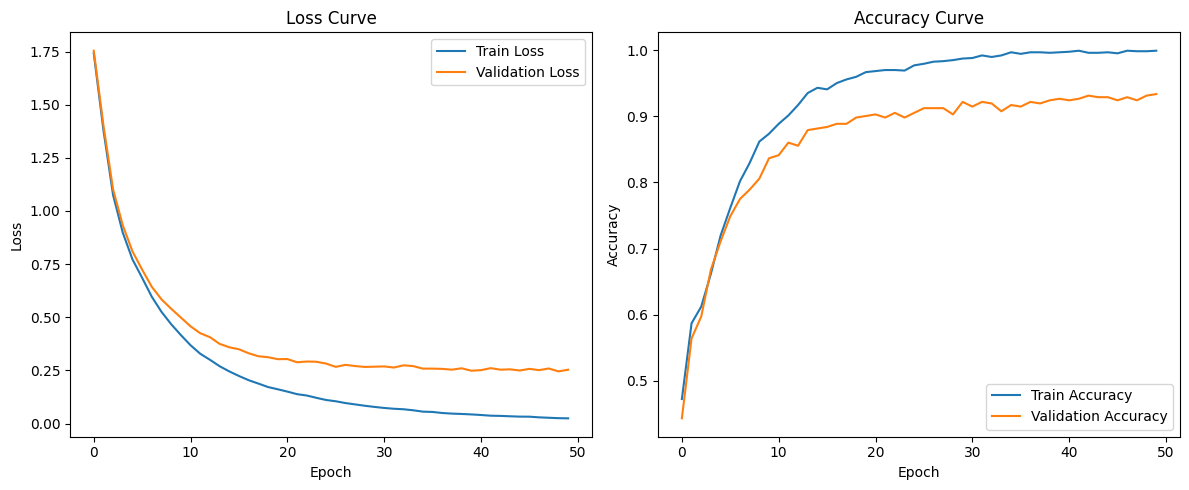

In [81]:
# Creating the loss function and optimizer
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)

# Training the model
epochs = 50

train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

best_val_acc = 0.0

for epoch in range(epochs):

    model.train()

    # Training on each batch
    for xb, yb in train_loader:

        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)

        optimizer.zero_grad()

        logits = model(xb)

        loss = criterion(logits, yb)

        loss.backward()

        optimizer.step()

    model.eval()

    train_loss_sum = 0
    train_correct = 0
    train_total = 0

    val_loss_sum = 0
    val_correct = 0
    val_total = 0

    # Evaluating the model
    with torch.no_grad():

        # Evaluating the training set
        for xb, yb in train_loader:

            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)

            logits = model(xb)

            loss = criterion(logits, yb)

            train_loss_sum += loss.item() * yb.size(0)

            predictions = logits.argmax(dim=1)

            train_correct += (predictions == yb).sum().item()
            train_total += yb.size(0)

        # Evaluating the validation set
        for xb, yb in val_loader:

            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)

            logits = model(xb)

            loss = criterion(logits, yb)

            val_loss_sum += loss.item() * xb.size(0)

            predictions = logits.argmax(dim=1)

            val_correct += (predictions == yb).sum().item()
            val_total += yb.size(0)

    train_loss = train_loss_sum / train_total
    train_accuracy = train_correct / train_total

    val_loss = val_loss_sum / val_total
    val_accuracy = val_correct / val_total

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)

    # Saving the best model
    if val_accuracy > best_val_acc:

        best_val_acc = val_accuracy

        torch.save(
            model.state_dict(),
            "ffn_best.pt"
        )

    print(
        f"Epoch {epoch + 1}/{epochs} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy * 100:.2f}% | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_accuracy * 100:.2f}%"
    )

# Plotting the loss curves
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")

plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()

# Plotting the accuracy curves
plt.subplot(1, 2, 2)

plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(val_accuracies, label="Validation Accuracy")

plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()

plt.tight_layout()

plt.show()



1. In the PyTorch training loop, logits = model(xb) performs the forward pass, loss.backward() computes the gradients using backpropagation, and optimizer.step() updates the model parameters using the optimizer.

2. The model is slightly overfitting. By the end of training, the training loss is about 0.03, while the validation loss is about 0.25. The training accuracy reaches almost 100%, whereas the validation accuracy levels off at about 93%. The gap between the training and validation performance indicates that the model has learned the training data better than the validation data, although the validation performance remains relatively high.

3. We call optimizer.zero_grad() before every batch to clear the gradients from the previous batch. Without it, PyTorch accumulates gradients across batches, causing incorrect weight updates and making training unstable or preventing the model from converging.

Part 2.4 - Experiments: how training choices change the outcome

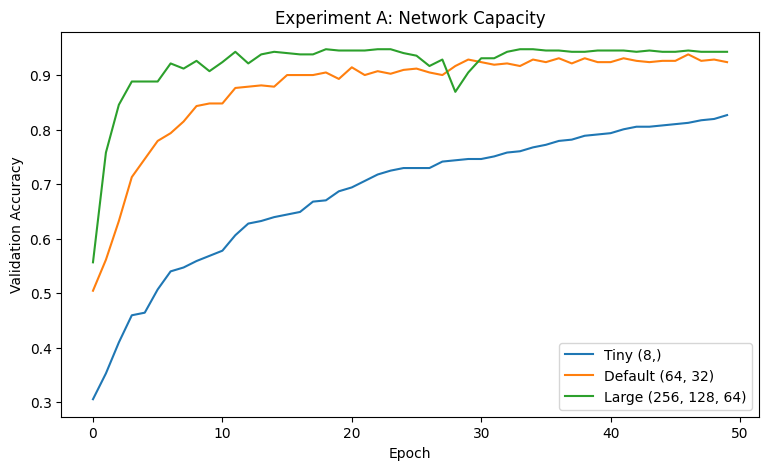

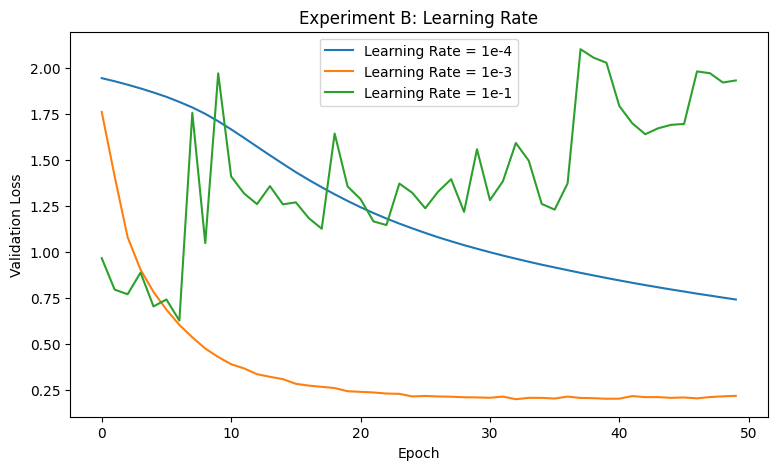

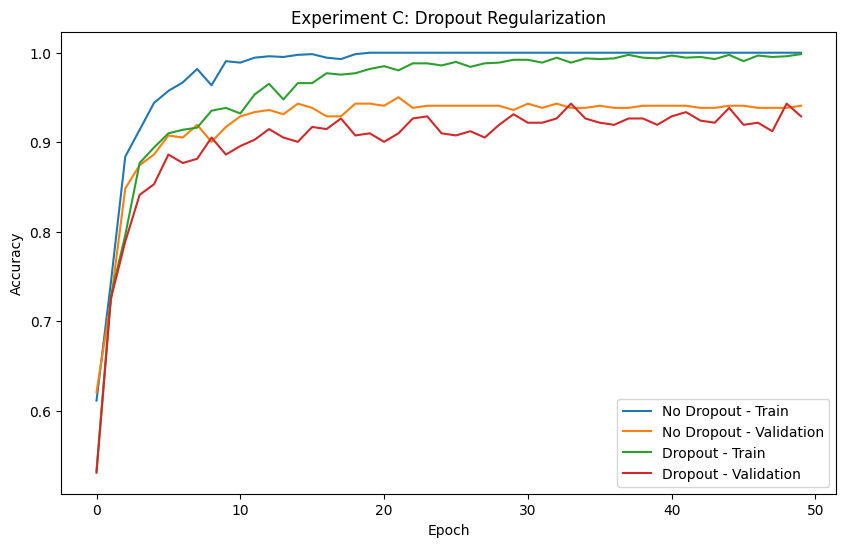

In [82]:
# Running the experiment
def run_experiment(
    hidden_sizes=(64, 32),
    lr=1e-3,
    batch_size=32,
    epochs=50,
    dropout=0.0
):

    # Creating the data loaders
    train_loader_exp = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True
    )

    val_loader_exp = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False
    )

    # Creating the model
    layers = []

    previous_size = x_train_tensor.shape[1]

    for hidden_size in hidden_sizes:

        layers.append(
            nn.Linear(previous_size, hidden_size)
        )

        layers.append(
            nn.ReLU()
        )

        if dropout > 0:

            layers.append(
                nn.Dropout(dropout)
            )

        previous_size = hidden_size

    layers.append(
        nn.Linear(previous_size, 7)
    )

    model = nn.Sequential(*layers).to(DEVICE)

    # Creating the loss function and optimizer
    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr
    )

    # Creating the lists to store the metrics
    train_losses = []
    val_losses = []

    train_accuracies = []
    val_accuracies = []

    best_val_acc = 0.0

    for epoch in range(epochs):

        # Training the model
        model.train()

        for xb, yb in train_loader_exp:

            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)

            optimizer.zero_grad()

            logits = model(xb)

            loss = criterion(logits, yb)

            loss.backward()

            optimizer.step()

        model.eval()

        train_loss_sum = 0
        train_correct = 0
        train_total = 0

        val_loss_sum = 0
        val_correct = 0
        val_total = 0

        # Evaluating the model
        with torch.no_grad():

            # Evaluating the training set
            for xb, yb in train_loader_exp:

                xb = xb.to(DEVICE)
                yb = yb.to(DEVICE)

                logits = model(xb)

                loss = criterion(logits, yb)

                train_loss_sum += loss.item() * yb.size(0)

                predictions = logits.argmax(dim=1)

                train_correct += (predictions == yb).sum().item()
                train_total += yb.size(0)

            # Evaluating the validation set
            for xb, yb in val_loader_exp:

                xb = xb.to(DEVICE)
                yb = yb.to(DEVICE)

                logits = model(xb)

                loss = criterion(logits, yb)

                val_loss_sum += loss.item() * yb.size(0)

                predictions = logits.argmax(dim=1)

                val_correct += (predictions == yb).sum().item()
                val_total += yb.size(0)

        # Calculating the metrics
        train_loss = train_loss_sum / train_total
        train_accuracy = train_correct / train_total

        val_loss = val_loss_sum / val_total
        val_accuracy = val_correct / val_total

        # Storing the metrics
        train_losses.append(train_loss)
        val_losses.append(val_loss)

        train_accuracies.append(train_accuracy)
        val_accuracies.append(val_accuracy)

        # Saving the best validation accuracy
        if val_accuracy > best_val_acc:

            best_val_acc = val_accuracy


    # Returning the training history
    history = {
        "train_loss": train_losses,
        "val_loss": val_losses,
        "train_accuracy": train_accuracies,
        "val_accuracy": val_accuracies
    }

    return history


# Running Experiment A
tiny_history = run_experiment(
    hidden_sizes=(8,)
)

default_history = run_experiment(
    hidden_sizes=(64, 32)
)

large_history = run_experiment(
    hidden_sizes=(256, 128, 64)
)

# Plotting the validation accuracy curves
plt.figure(figsize=(9, 5))

plt.plot(
    tiny_history["val_accuracy"],
    label="Tiny (8,)"
)

plt.plot(
    default_history["val_accuracy"],
    label="Default (64, 32)"
)

plt.plot(
    large_history["val_accuracy"],
    label="Large (256, 128, 64)"
)

plt.title("Experiment A: Network Capacity")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()

plt.show()


# Running Experiment B
lr_small_history = run_experiment(
    hidden_sizes=(64, 32),
    lr=1e-4
)

lr_default_history = run_experiment(
    hidden_sizes=(64, 32),
    lr=1e-3
)

lr_large_history = run_experiment(
    hidden_sizes=(64, 32),
    lr=1e-1
)

# Plotting the validation loss curves
plt.figure(figsize=(9, 5))

plt.plot(
    lr_small_history["val_loss"],
    label="Learning Rate = 1e-4"
)

plt.plot(
    lr_default_history["val_loss"],
    label="Learning Rate = 1e-3"
)

plt.plot(
    lr_large_history["val_loss"],
    label="Learning Rate = 1e-1"
)

plt.title("Experiment B: Learning Rate")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.legend()

plt.show()


# Running Experiment C
no_dropout_history = run_experiment(
    hidden_sizes=(256, 128, 64),
    dropout=0.0
)

dropout_history = run_experiment(
    hidden_sizes=(256, 128, 64),
    dropout=0.3
)

# Plotting the training and validation accuracy curves
plt.figure(figsize=(10, 6))

plt.plot(
    no_dropout_history["train_accuracy"],
    label="No Dropout - Train"
)

plt.plot(
    no_dropout_history["val_accuracy"],
    label="No Dropout - Validation"
)

plt.plot(
    dropout_history["train_accuracy"],
    label="Dropout - Train"
)

plt.plot(
    dropout_history["val_accuracy"],
    label="Dropout - Validation"
)

plt.title("Experiment C: Dropout Regularization")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

1. The largest network achieved the highest validation accuracy (about 94%), while the default network reached about 93% and the tiny network reached about 83%. However, the improvement from the default network to the largest network was small, showing diminishing returns. The largest network also showed signs of slight overfitting because its training performance was much higher than its validation performance.

2. Yes. The learning rates behaved similarly to the toy problem in Part 1.3. The learning rate of 1e-4 learned very slowly, 1e-3 converged quickly and produced the lowest validation loss, while 1e-1 caused the validation loss to fluctuate and become unstable because the updates were too large.

3. Dropout reduced the gap between the training and validation accuracies by lowering the training accuracy while maintaining a similar validation accuracy. It achieves this by randomly deactivating some neurons during training, preventing the network from relying too heavily on specific neurons and reducing overfitting.

Part 2.5 - Final evaluation and showdown


Test Accuracy: 0.9314
Macro F1: 0.9285
                     precision    recall  f1-score   support

Insufficient_Weight       0.93      0.98      0.95        54
      Normal_Weight       0.92      0.76      0.83        58
     Obesity_Type_I       0.95      1.00      0.97        70
    Obesity_Type_II       0.98      0.97      0.97        60
   Obesity_Type_III       1.00      0.98      0.99        65
 Overweight_Level_I       0.80      0.90      0.85        58
Overweight_Level_II       0.95      0.91      0.93        58

           accuracy                           0.93       423
          macro avg       0.93      0.93      0.93       423
       weighted avg       0.93      0.93      0.93       423



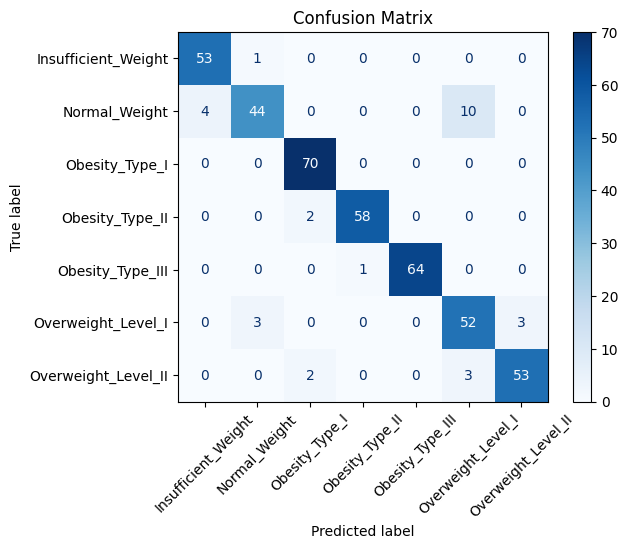

,Model,Test Accuracy,Macro F1,Training Time,Architecture
0,Random Forest,0.978700,0.978300,Short,100 Trees
1,FeedForward Network,0.931442,0.928537,Longer,64-32 FeedForward Network


In [84]:
# Importing the evaluation metrics
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay

# Creating the best model
input_dim = x_train_tensor.shape[1]

best_model = FeedForwardNet(
    input_dim=input_dim,
    hidden_sizes=(64, 32),
    n_classes=7
).to(DEVICE)

# Loading the saved model
best_model.load_state_dict(
    torch.load("ffn_best.pt")
)

best_model.eval()

# Creating lists to store the predictions
y_true = []
y_pred = []

# Evaluating the model
with torch.no_grad():

    for xb, yb in test_loader:

        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)

        logits = best_model(xb)

        predictions = logits.argmax(dim=1)

        y_true.extend(
            yb.cpu().numpy()
        )

        y_pred.extend(
            predictions.cpu().numpy()
        )

# Calculating the evaluation metrics
test_accuracy = accuracy_score(
    y_true,
    y_pred
)

test_f1 = f1_score(
    y_true,
    y_pred,
    average="macro"
)

print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Macro F1: {test_f1:.4f}")

print(
    classification_report(
        y_true,
        y_pred,
        target_names=label_encoder.classes_
    )
)

# Plotting the confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_true,
    y_pred,
    display_labels=label_encoder.classes_,
    xticks_rotation=45,
    cmap="Blues"
)

plt.title("Confusion Matrix")

plt.show()

# Creating the comparison table
comparison = pd.DataFrame({

    "Model": [
        "Random Forest",
        "FeedForward Network"
    ],

    "Test Accuracy": [
        0.9787,
        test_accuracy
    ],

    "Macro F1": [
        0.9783,
        test_f1
    ],

    "Training Time": [
        "Short",
        "Longer"
    ],

    "Architecture": [
        "100 Trees",
        "64-32 FeedForward Network"
    ]

})

comparison


1. The network still confused some neighbouring obesity classes. The largest confusion was between Normal_Weight and Overweight_Level_I, where 10 Normal_Weight samples were classified as Overweight_Level_I. There were also a few misclassifications between Obesity_Type_I and Obesity_Type_II, Overweight_Level_I and Overweight_Level_II, and Insufficient_Weight and Normal_Weight. These are similar to the confusions observed in the Lab 2 Random Forest classifier, where neighbouring obesity categories were also the most difficult to distinguish.

2. The Random Forest won the comparison. It achieved a higher test accuracy (97.87%) and Macro F1 score (97.83%) than the FeedForward Network, which achieved a test accuracy of 93.14% and a Macro F1 score of 92.85%. It also trained faster. Therefore, the extra effort of using deep learning was not worthwhile for this tabular dataset. Deep learning would be more beneficial for complex datasets such as images, audio, text, or very large datasets where neural networks can learn more complex patterns than classical machine learning models.

SECTION 3 - Reflection

1. Inside loss.backward(), the network performs backpropagation by computing the gradients of the loss with respect to every trainable parameter. These gradients show how each weight contributed to the error. Then, optimizer.step() uses these gradients to update the weights in the direction that reduces the loss.

2. If I could tune only one hyperparameter, I would choose the learning rate because it has the greatest impact on how quickly and how well the model learns. A learning rate that is too small makes training slow, while one that is too large can make training unstable or prevent convergence.

3. The biggest training-versus-validation gap occurred with the largest network and with training without dropout, indicating overfitting. Adding dropout reduced this gap by preventing the network from relying too much on individual neurons, which improved its ability to generalise to unseen data.

4. A plain MLP treats every pixel independently and does not take advantage of the spatial relationships between neighbouring pixels. A better architecture should be able to detect local patterns and preserve spatial information, allowing it to recognise features such as edges, shapes, and textures more effectively.